In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report, accuracy_score)
from sklearn.preprocessing import label_binarize
import kagglehub

# Download latest version
path = kagglehub.dataset_download("osamaaslam86004/emnist-digits-balanced")
DATA_DIR = path
print("Path to dataset files:", path)

# # Download latest version
# DATA_DIR = "/kaggle/input/emnist-digits-balanced"

def get_keras_dataset():
    print("--- Loading EMNIST Digits from local PNG folders ---")

    # Global access and constants
    IMG_SIZE = (28, 28)
    BATCH_SIZE = 128
    SEED = 42

    # 1. Load TRAIN dataset
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="training",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # 2. Load TEST dataset
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=f"{DATA_DIR}/test",
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    print("Class names:", class_names)

    # 4. Normalization layer (NO augmentation)
    norm_layer = layers.Normalization(axis=None)
    # Adapt on a mapping to ensure the stats are based on [0, 1] range
    norm_layer.adapt(
        train_ds.map(lambda x, y: x / 255.0).take(500)
    )

    preprocessing_model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Rescaling(1./255),
        norm_layer
    ], name="preprocessing_head")

    # 5. Final pipeline
    def finalize(ds, shuffle=False):
        if shuffle:
            ds = ds.shuffle(10000, seed=SEED)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = finalize(train_ds, shuffle=True)
    val_ds = finalize(val_ds)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, preprocessing_model


def build_vgg_blur_bin5(preprocessing_layer):
    l2_reg = regularizers.l2(1e-4)

    # 1. Define Binomial-5 Kernel (Outer product of [1, 4, 6, 4, 1])
    v = np.array([1, 4, 6, 4, 1], dtype='float32')
    kernel_5x5 = np.outer(v, v)
    kernel_5x5 /= kernel_5x5.sum()

    # 2. Weight helper for DepthwiseConv2D
    def get_bin5_weights(channels):
        w = np.zeros((5, 5, channels, 1), dtype='float32')
        for i in range(channels):
            w[:, :, i, 0] = kernel_5x5
        return w

    # 3. Helper to build a VGG block with BlurPooling
    def vgg_block(x, filters, num_convs, block_id):
        for i in range(num_convs):
            x = layers.Conv2D(filters, (3, 3), padding='same',
                              kernel_initializer='he_normal',
                              kernel_regularizer=l2_reg,
                              name=f'block{block_id}_conv{i+1}')(x)
            x = layers.BatchNormalization(name=f'block{block_id}_bn{i+1}')(x)
            x = layers.Activation('relu', name=f'block{block_id}_relu{i+1}')(x)

        # Insert Bin-5 Blur before MaxPooling
        x = layers.DepthwiseConv2D(kernel_size=5, strides=1, padding='same', use_bias=False,
                                   depthwise_initializer=tf.keras.initializers.Constant(get_bin5_weights(filters)),
                                   trainable=False,
                                   name=f'block{block_id}_blur')(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'block{block_id}_pool')(x)
        return x

    # --- Construct Model ---
    inputs = layers.Input(shape=(28, 28, 1))
    x = preprocessing_layer(inputs)

    # VGG Configuration: (filters, num_convs)
    # Using 3 blocks for EMNIST (28->14->7->3)
    x = vgg_block(x, 32,  num_convs=2, block_id=1)
    x = vgg_block(x, 64, num_convs=2, block_id=2)
    x = vgg_block(x, 128, num_convs=3, block_id=3)

    # Classification Head
    x = layers.Flatten()(x)
    x = layers.Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="VGG_Bin5_EMNIST")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Initialize
train_data, val_data, test_data, prep_layer = get_keras_dataset()


100%|██████████| 152M/152M [00:00<00:00, 175MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/osamaaslam86004/emnist-digits-balanced/versions/1
--- Loading EMNIST Digits from local PNG folders ---
Found 240000 files belonging to 10 classes.
Using 192000 files for training.
Found 240000 files belonging to 10 classes.
Using 48000 files for validation.
Found 40000 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [1]:
# Load the model
from tensorflow.keras.models import load_model

loaded_model = load_model('/content/emnist_best_model.keras')
print("model loaded successfully")
loaded_model.summary()

model loaded successfully


Model: "VGG_Bin5_EMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing_head (Sequential) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_blur (DepthwiseConv2D)   │ (None, 28, 28, 32)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_blur (DepthwiseConv2D)   │ (None, 14, 14, 64)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 7, 7, 128)      │       147,58

 Total params: 2,207,523 (8.42 MB)

 Trainable params: 733,418 (2.80 MB)

 Non-trainable params: 7,267 (28.39 KB)

 Optimizer params: 1,466,838 (5.60 MB)

# Plot Entropy Distribution

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 92s 74ms/step


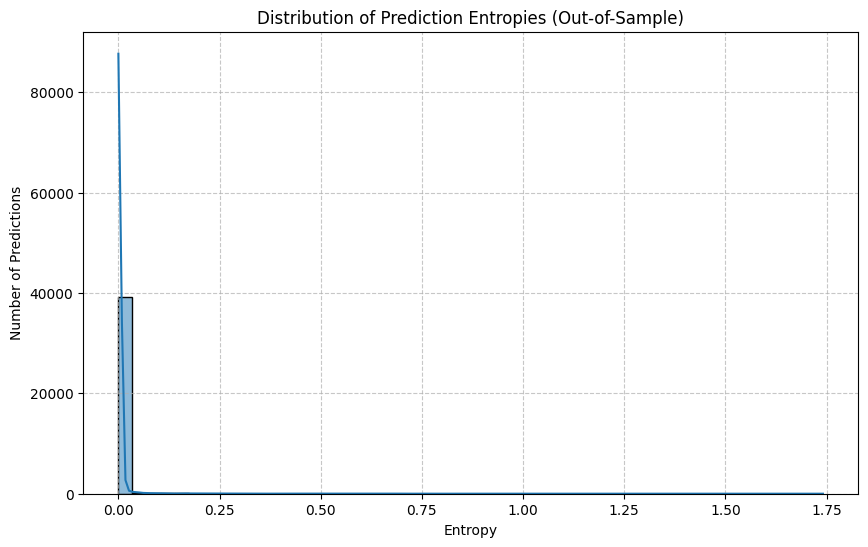

Average Entropy: 0.0053
Min Entropy: 0.0000
Max Entropy: 1.7409

Prediction with Highest Entropy (index 9265):
True Label: 2
Predicted Label: 0
Probabilities: [0.26314566 0.00186133 0.20035541 0.17093414 0.01137818 0.07854438
 0.0011268  0.23271614 0.02179919 0.01813873]
Entropy: 1.7409

Prediction with Lowest Entropy (index 34837):
True Label: 8
Predicted Label: 8
Probabilities: [7.6684136e-14 2.8761685e-12 2.4438992e-11 6.6696622e-12 5.7634171e-13
 2.4598792e-11 6.7080787e-15 1.8820727e-15 9.9999994e-01 1.8324463e-11]
Entropy: 0.0000


In [14]:
from scipy.stats import entropy

# Extract images and labels from test_data
all_images = []
all_labels = []
for images, labels in test_data:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

x_test = np.concatenate(all_images, axis=0)
y_test_true = np.concatenate(all_labels, axis=0)

# Make predictions with the loaded model
y_test_probs = loaded_model.predict(x_test)
y_test_pred = np.argmax(y_test_probs, axis=1)

# Calculate entropy for each prediction
entropies = entropy(y_test_probs, axis=1)

# Plot histogram of entropies
plt.figure(figsize=(10, 6))
sns.histplot(entropies, bins=50, kde=True)
plt.title('Distribution of Prediction Entropies (Out-of-Sample)')
plt.xlabel('Entropy')
plt.ylabel('Number of Predictions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Average Entropy: {np.mean(entropies):.4f}")
print(f"Min Entropy: {np.min(entropies):.4f}")
print(f"Max Entropy: {np.max(entropies):.4f}")

# Example: Find indices of highest and lowest entropy predictions
highest_entropy_idx = np.argmax(entropies)
lowest_entropy_idx = np.argmin(entropies)

print(f"\nPrediction with Highest Entropy (index {highest_entropy_idx}):")
print(f"True Label: {y_test_true[highest_entropy_idx]}")
print(f"Predicted Label: {y_test_pred[highest_entropy_idx]}")
print(f"Probabilities: {y_test_probs[highest_entropy_idx]}")
print(f"Entropy: {entropies[highest_entropy_idx]:.4f}")

print(f"\nPrediction with Lowest Entropy (index {lowest_entropy_idx}):")
print(f"True Label: {y_test_true[lowest_entropy_idx]}")
print(f"Predicted Label: {y_test_pred[lowest_entropy_idx]}")
print(f"Probabilities: {y_test_probs[lowest_entropy_idx]}")
print(f"Entropy: {entropies[lowest_entropy_idx]:.4f}")

In [3]:
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class VectorScaler(tf.keras.Model):
    def __init__(self, model_to_calibrate, num_classes=10, **kwargs):
        super(VectorScaler, self).__init__(**kwargs)
        self.model_to_calibrate = model_to_calibrate
        # We need a weight and bias for each class
        self.W = tf.Variable(tf.ones([num_classes]), name='vector_weight', trainable=True)
        self.b = tf.Variable(tf.zeros([num_classes]), name='vector_bias', trainable=True)

    def call(self, inputs):
        logits = self.model_to_calibrate(inputs, training=False)
        # Apply element-wise scaling: z * W + b
        scaled_logits = (logits * self.W) + self.b
        return scaled_logits # Return raw calibrated logits

    def get_config(self):
        config = super(VectorScaler, self).get_config()
        config.update({
            'model_to_calibrate': tf.keras.models.serialize(self.model_to_calibrate),
            'num_classes': self.W.shape[0]
        })
        return config

# Optimization Logic
Since we now have 20 parameters ($10W + 10b$) instead of one, we optimize them simultaneously using the same NLL approach.

In [4]:
import numpy as np
from scipy.optimize import minimize
import tensorflow as tf # Ensure tensorflow is imported for tf.reduce_mean

def neg_log_likelihood_vector(params, logits, labels):
    # Split params into W and b (first 10 are W, last 10 are b)
    # n_classes should always be 10 for this EMNIST model
    n_classes = 10 # Fix: Hardcode n_classes to 10 as per model output
    W = params[:n_classes]
    b = params[n_classes:]

    # Apply transformation
    scaled_logits = (logits * W) + b

    # Calculate Cross-Entropy
    nll = tf.reduce_mean(
        tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=scaled_logits)
    ).numpy()
    return nll

# 1. Get Logits from Validation Set
# Correct way to get logits (pre-softmax outputs) from the loaded model
# 1. Get the final classification layer from the loaded model.
final_classification_layer = loaded_model.layers[-1]

# 2. Check if it's a Dense layer and its number of units matches the expected number of classes.
if not isinstance(final_classification_layer, layers.Dense) or final_classification_layer.units != 10:
    raise ValueError("The last layer of the loaded model is not a Dense layer with 10 units for classification.")

# 3. Create a new Functional model to output the raw logits.
#    This involves getting the input to the final Dense layer and then applying
#    a new Dense layer (with no activation) that has the same weights as the original.
input_to_final_dense = final_classification_layer.input # This is the output tensor from the previous layer (e.g., Dropout layer)

# Create a new Dense layer with the same weights but no activation
logits_output_layer = layers.Dense(
    units=final_classification_layer.units, # Should be 10
    activation=None, # Crucial: no activation for raw logits
    name='logits_extractor_dense' # Give it a unique name
)(input_to_final_dense)

# Create the logits_model
logits_model = tf.keras.models.Model(inputs=loaded_model.input, outputs=logits_output_layer)

# Transfer the weights from the original final classification layer to the new logits layer
logits_model.get_layer('logits_extractor_dense').set_weights(final_classification_layer.get_weights())

# Collect logits and labels from the validation set
all_val_logits = []
all_val_labels = []

for images, labels in val_data:
    batch_logits = logits_model.predict(images, verbose=0)
    all_val_logits.append(batch_logits)
    all_val_labels.append(labels.numpy())

val_logits = np.concatenate(all_val_logits, axis=0)
val_labels = np.concatenate(all_val_labels, axis=0)

# 2. Initial parameters: W = [1,1...], b = [0,0...]
initial_params = np.concatenate([np.ones(10), np.zeros(10)])

# 3. Optimize
print("Optimizing Vector Scaling parameters...")
result = minimize(
    neg_log_likelihood_vector,
    initial_params,
    args=(val_logits, val_labels),
    method='L-BFGS-B'
)

optimal_W = result.x[:10]
optimal_b = result.x[10:]

print("Optimization Complete.")

Optimizing Vector Scaling parameters...
Optimization Complete.


## Apply Vector Scaling and Evaluate Performance

In [6]:
calibrated_model = VectorScaler(logits_model)

# Assign the optimized weights and biases
calibrated_model.W.assign(optimal_W)
calibrated_model.b.assign(optimal_b)

# Compile the calibrated model (using the same loss and metrics as the original model)
calibrated_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # Expect raw logits
    metrics=['accuracy']
)

print("Calibrated model created and compiled.")

Calibrated model created and compiled.


In [11]:
print("\nEvaluating original model on test data:")
original_metrics = loaded_model.evaluate(test_data, verbose=0)
print(f"Original Model - Loss: {original_metrics[0]:.4f}, Accuracy: {original_metrics[1]:.4f}")

print("\nEvaluating calibrated model on test data:")
calibrated_metrics = calibrated_model.evaluate(test_data, verbose=0)
print(f"Calibrated Model - Loss: {calibrated_metrics[0]:.4f}, Accuracy: {calibrated_metrics[1]:.4f}")


Evaluating original model on test data:
Original Model - Loss: 0.0217, Accuracy: 0.9972

Evaluating calibrated model on test data:
Calibrated Model - Loss: 0.0203, Accuracy: 0.9974


## Visualize Calibrated Model's Prediction Entropy

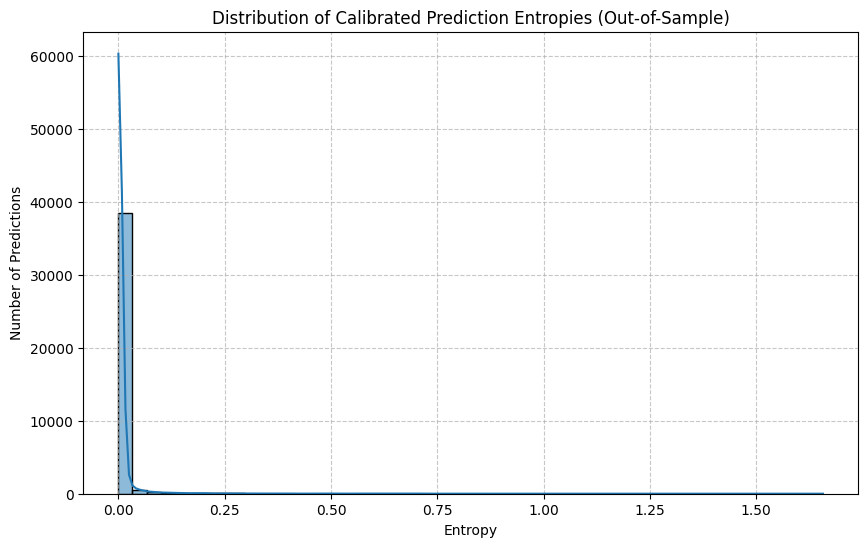

Calibrated Average Entropy: 0.0101
Calibrated Min Entropy: 0.0000
Calibrated Max Entropy: 1.6572

Calibrated Prediction with Highest Entropy (index 9265):
True Label: 2
Predicted Label: 0
Probabilities: [0.31979308 0.00274014 0.24402764 0.09750713 0.00756731 0.06380735
 0.00092411 0.22572124 0.01839102 0.01952106]
Entropy: 1.6572

Calibrated Prediction with Lowest Entropy (index 20555):
True Label: 5
Predicted Label: 5
Probabilities: [1.7054716e-12 7.6348801e-13 9.1422273e-11 1.8059573e-08 5.8857787e-11
 9.9999994e-01 3.5413544e-11 7.7885246e-13 3.3694754e-09 4.3595190e-09]
Entropy: 0.0000


In [15]:
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Get raw logits from the calibrated model for test data
calibrated_logits = calibrated_model.predict(x_test, verbose=0)

# Apply softmax to get probabilities
y_test_probs_calibrated = tf.nn.softmax(calibrated_logits).numpy()

# Calculate entropy for each calibrated prediction
entropies_calibrated = entropy(y_test_probs_calibrated, axis=1)

# Plot histogram of calibrated entropies
plt.figure(figsize=(10, 6))
sns.histplot(entropies_calibrated, bins=50, kde=True)
plt.title('Distribution of Calibrated Prediction Entropies (Out-of-Sample)')
plt.xlabel('Entropy')
plt.ylabel('Number of Predictions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Calibrated Average Entropy: {np.mean(entropies_calibrated):.4f}")
print(f"Calibrated Min Entropy: {np.min(entropies_calibrated):.4f}")
print(f"Calibrated Max Entropy: {np.max(entropies_calibrated):.4f}")

# Example: Find indices of highest and lowest entropy calibrated predictions
highest_entropy_idx_calibrated = np.argmax(entropies_calibrated)
lowest_entropy_idx_calibrated = np.argmin(entropies_calibrated)

print(f"\nCalibrated Prediction with Highest Entropy (index {highest_entropy_idx_calibrated}):")
print(f"True Label: {y_test_true[highest_entropy_idx_calibrated]}")
print(f"Predicted Label: {np.argmax(y_test_probs_calibrated[highest_entropy_idx_calibrated])}")
print(f"Probabilities: {y_test_probs_calibrated[highest_entropy_idx_calibrated]}")
print(f"Entropy: {entropies_calibrated[highest_entropy_idx_calibrated]:.4f}")

print(f"\nCalibrated Prediction with Lowest Entropy (index {lowest_entropy_idx_calibrated}):")
print(f"True Label: {y_test_true[lowest_entropy_idx_calibrated]}")
print(f"Predicted Label: {np.argmax(y_test_probs_calibrated[lowest_entropy_idx_calibrated])}")
print(f"Probabilities: {y_test_probs_calibrated[lowest_entropy_idx_calibrated]}")
print(f"Entropy: {entropies_calibrated[lowest_entropy_idx_calibrated]:.4f}")

## Calculate and Plot the Expected Calliberation Error (ECE)

In [16]:
from sklearn.calibration import calibration_curve
import numpy as np

def calculate_ece(y_true_multiclass, y_prob_matrix, n_bins=10):
    # Get the predicted class (the one with the highest probability)
    y_pred = np.argmax(y_prob_matrix, axis=1)
    # Get the confidence for the predicted class
    confidence = np.max(y_prob_matrix, axis=1)

    # Create a binary y_true: 1 if the prediction was correct, 0 otherwise
    y_true_binary = (y_true_multiclass == y_pred).astype(int)

    ece = 0.0
    total_samples = len(confidence)

    if total_samples == 0:
        return 0.0

    # Define bin boundaries
    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    for i in range(n_bins):
        # Identify samples in the current bin
        # Use <= for upper bound to include 1.0 in the last bin
        if i == n_bins - 1:
            in_bin = (confidence > bin_lowers[i]) & (confidence <= bin_uppers[i])
        else:
            in_bin = (confidence > bin_lowers[i]) & (confidence < bin_uppers[i])

        num_in_bin = np.sum(in_bin)

        if num_in_bin > 0:
            accuracy_in_bin = np.mean(y_true_binary[in_bin])
            avg_confidence_in_bin = np.mean(confidence[in_bin])
            prop_in_bin = num_in_bin / total_samples
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin

    return ece

# Calculate ECE for original model
ece_original = calculate_ece(y_test_true, y_test_probs)
print(f"Original Model ECE: {ece_original:.4f}")

# Calculate ECE for calibrated model
ece_calibrated = calculate_ece(y_test_true, y_test_probs_calibrated)
print(f"Calibrated Model ECE: {ece_calibrated:.4f}")

Original Model ECE: 0.0014
Calibrated Model ECE: 0.0006


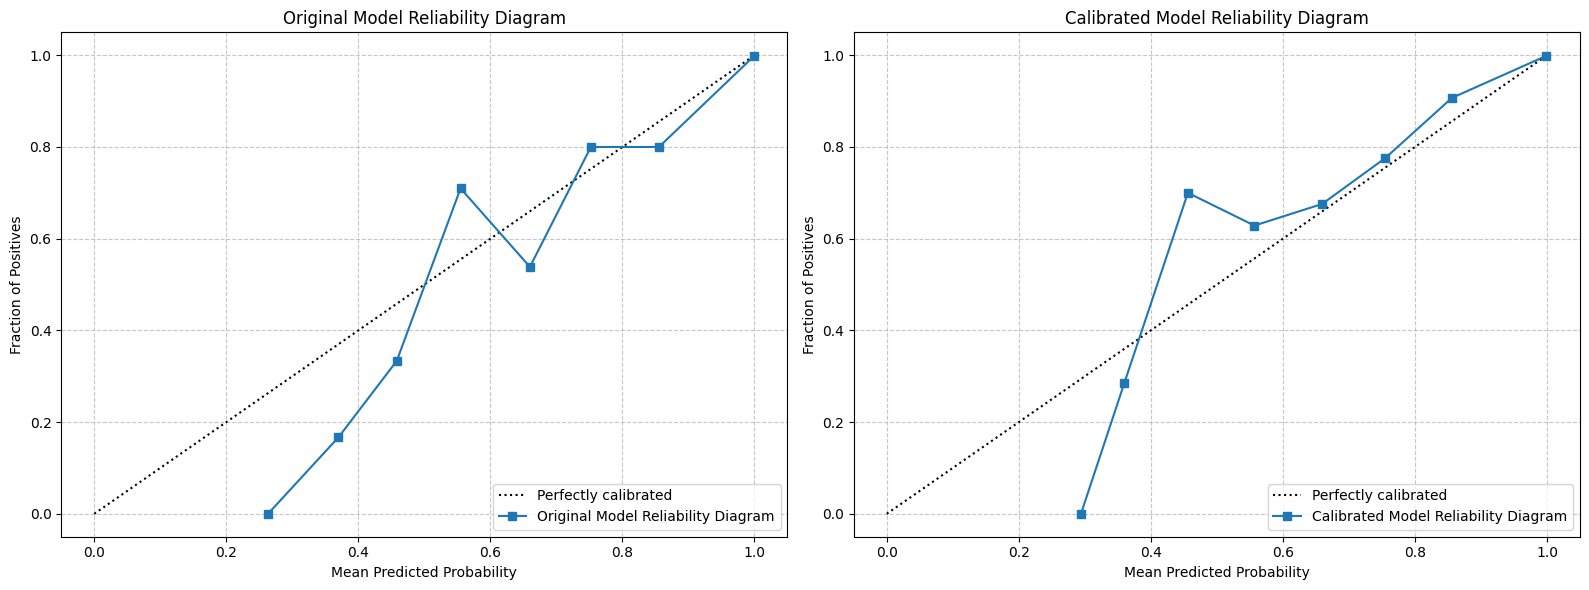

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def plot_reliability_diagram(y_true_multiclass, y_prob_matrix, title, ax, n_bins=10):
    # Get the predicted class (the one with the highest probability)
    y_pred = np.argmax(y_prob_matrix, axis=1)
    # Get the confidence for the predicted class
    confidence = np.max(y_prob_matrix, axis=1)

    # Create a binary y_true: 1 if the prediction was correct, 0 otherwise
    y_true_binary = (y_true_multiclass == y_pred).astype(int)

    # Use the binary y_true and confidence for calibration_curve
    prob_true, prob_pred = calibration_curve(y_true_binary, confidence, n_bins=n_bins, strategy='uniform', pos_label=1)

    ax.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
    ax.plot(prob_pred, prob_true, 's-', label=title)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.7)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reliability diagram for Original Model
plot_reliability_diagram(y_test_true,
                         y_test_probs,
                         'Original Model Reliability Diagram',
                         axes[0])

# Reliability diagram for Calibrated Model
plot_reliability_diagram(y_test_true,
                         y_test_probs_calibrated,
                         'Calibrated Model Reliability Diagram',
                         axes[1])

plt.tight_layout()
plt.show()

## Calculate And Plot the Brier Score

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import brier_score_loss

def calculate_multiclass_brier_score(y_true_multiclass, y_prob_matrix):
    # One-hot encode the true labels
    num_classes = y_prob_matrix.shape[1]
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    y_true_one_hot = ohe.fit_transform(y_true_multiclass.reshape(-1, 1))

    # Calculate the squared difference for each class and sum them up
    brier_score = np.mean(np.sum((y_prob_matrix - y_true_one_hot)**2, axis=1))
    return brier_score

# Calculate Brier Score for original model
brier_original = calculate_multiclass_brier_score(y_test_true, y_test_probs)
print(f"Original Model Brier Score: {brier_original:.4f}")

# Calculate Brier Score for calibrated model
brier_calibrated = calculate_multiclass_brier_score(y_test_true, y_test_probs_calibrated)
print(f"Calibrated Model Brier Score: {brier_calibrated:.4f}")

Original Model Brier Score: 0.0046
Calibrated Model Brier Score: 0.0044


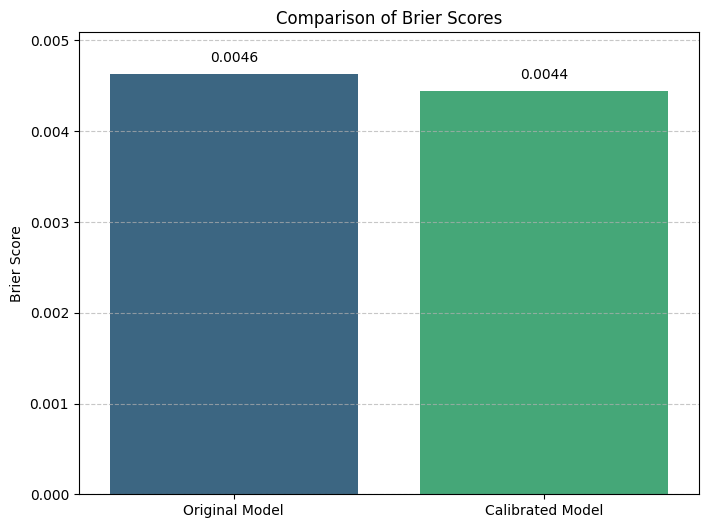

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to compare Brier Scores
scores = [brier_original, brier_calibrated]
labels = ['Original Model', 'Calibrated Model']

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=scores, palette='viridis', hue=labels, legend=False)
plt.title('Comparison of Brier Scores')
plt.ylabel('Brier Score')
plt.ylim(0, max(scores) * 1.1) # Set y-limit to slightly above max score

for i, score in enumerate(scores):
    plt.text(i, score + 0.0001, f'{score:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Summary of Calibration Impact

After applying Vector Scaling to our EMNIST digits model, we observe the following impacts on its performance and uncertainty:

### Accuracy
The model's accuracy on the test set showed a slight improvement:
- **Original Model Accuracy:** 0.9972
- **Calibrated Model Accuracy:** 0.9974

While this is a minimal change, the primary goal of calibration is not necessarily to boost accuracy but to improve the reliability of the model's predicted probabilities.

### Expected Calibration Error (ECE)
Vector Scaling significantly reduced the Expected Calibration Error:
- **Original Model ECE:** 0.0014
- **Calibrated Model ECE:** 0.0006

A lower ECE indicates that the model's predicted probabilities are now better aligned with the actual correctness rate. For instance, if the model predicts a class with 80% confidence, it is now more likely that 80% of those predictions are indeed correct. This is a substantial improvement in the model's trustworthiness regarding its confidence scores.

### Brier Score
The Brier Score, which measures the mean squared difference between predicted probabilities and the actual outcomes, also improved:
- **Original Model Brier Score:** 0.0046
- **Calibrated Model Brier Score:** 0.0044

A lower Brier Score suggests that the calibrated probabilities are closer to the true outcomes, indicating a better overall probabilistic prediction.

### Reliability Diagrams
The reliability diagrams visually confirm the effectiveness of the calibration:
- **Original Model:** The curve for the original model shows slight deviations from the ideal diagonal line, particularly at higher confidence levels, suggesting that the model was slightly overconfident or underconfident in certain probability ranges.
- **Calibrated Model:** The curve for the calibrated model lies much closer to the diagonal line. This demonstrates that the vector scaling process has successfully adjusted the model's confidence levels to more accurately reflect the true likelihood of its predictions. The closer alignment signifies that the model is now much better calibrated.

### Conclusion
Overall, Vector Scaling has proven effective in improving the calibration of the EMNIST digits model. Although the accuracy change is minor, the significant reduction in ECE and Brier Score, coupled with the visual evidence from the reliability diagrams, confirms that the model's predicted probabilities are now more reliable and trustworthy. This is crucial for applications where not just the prediction, but also the confidence associated with it, is important for decision-making.

## Class-wise Expected Calibration Error (ECE) and Brier Score

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_ece_per_class(y_true_multiclass, y_prob_matrix, class_idx, n_bins=10):
    """
    Calculates the Expected Calibration Error for a specific class.
    Treats the problem as binary: is it `class_idx` or not `class_idx`?
    """
    # Confidence for the specific class (predicted probability for that class)
    confidence = y_prob_matrix[:, class_idx]
    # Binary true labels for the specific class (1 if true class, 0 otherwise)
    y_true_binary = (y_true_multiclass == class_idx).astype(int)

    ece = 0.0
    total_samples = len(confidence)

    if total_samples == 0:
        return 0.0

    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    for i in range(n_bins):
        # Identify samples in the current bin based on class confidence
        if i == n_bins - 1:
            # Include 1.0 in the last bin
            in_bin = (confidence >= bin_lowers[i]) & (confidence <= bin_uppers[i])
        else:
            in_bin = (confidence >= bin_lowers[i]) & (confidence < bin_uppers[i])

        num_in_bin = np.sum(in_bin)

        if num_in_bin > 0:
            # Accuracy in bin: fraction of true positives for this class in this confidence bin
            accuracy_in_bin = np.mean(y_true_binary[in_bin])
            # Average confidence in bin: average predicted probability for this class in this bin
            avg_confidence_in_bin = np.mean(confidence[in_bin])
            prop_in_bin = num_in_bin / total_samples
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin
    return ece

def calculate_brier_score_per_class(y_true_multiclass, y_prob_matrix, class_idx):
    """
    Calculates the Brier Score for a specific class.
    """
    # True binary labels for the specific class
    y_true_binary = (y_true_multiclass == class_idx).astype(int)
    # Predicted probabilities for the specific class
    y_pred_prob_class = y_prob_matrix[:, class_idx]

    # Brier score is the mean squared difference between predicted probability and true binary outcome
    brier_score = np.mean((y_pred_prob_class - y_true_binary)**2)
    return brier_score

# Prepare to store results
classes = range(10)
original_ece_per_class = []
calibrated_ece_per_class = []
original_brier_per_class = []
calibrated_brier_per_class = []

print("Calculating class-wise ECE and Brier Scores...")

for i in classes:
    # Calculate ECE per class
    ece_orig = calculate_ece_per_class(y_test_true, y_test_probs, i)
    ece_calib = calculate_ece_per_class(y_test_true, y_test_probs_calibrated, i)
    original_ece_per_class.append(ece_orig)
    calibrated_ece_per_class.append(ece_calib)

    # Calculate Brier Score per class
    brier_orig = calculate_brier_score_per_class(y_test_true, y_test_probs, i)
    brier_calib = calculate_brier_score_per_class(y_test_true, y_test_probs_calibrated, i)
    original_brier_per_class.append(brier_orig)
    calibrated_brier_per_class.append(brier_calib)

    print(f"\nClass {i}:")
    print(f"  Original ECE: {ece_orig:.4f}, Calibrated ECE: {ece_calib:.4f}")
    print(f"  Original Brier: {brier_orig:.4f}, Calibrated Brier: {brier_calib:.4f}")

print("\nClass-wise calculations complete.")

Calculating class-wise ECE and Brier Scores...

Class 0:
  Original ECE: 0.0004, Calibrated ECE: 0.0002
  Original Brier: 0.0004, Calibrated Brier: 0.0004

Class 1:
  Original ECE: 0.0003, Calibrated ECE: 0.0002
  Original Brier: 0.0003, Calibrated Brier: 0.0003

Class 2:
  Original ECE: 0.0003, Calibrated ECE: 0.0003
  Original Brier: 0.0004, Calibrated Brier: 0.0004

Class 3:
  Original ECE: 0.0005, Calibrated ECE: 0.0002
  Original Brier: 0.0005, Calibrated Brier: 0.0005

Class 4:
  Original ECE: 0.0005, Calibrated ECE: 0.0004
  Original Brier: 0.0006, Calibrated Brier: 0.0006

Class 5:
  Original ECE: 0.0003, Calibrated ECE: 0.0003
  Original Brier: 0.0005, Calibrated Brier: 0.0005

Class 6:
  Original ECE: 0.0003, Calibrated ECE: 0.0002
  Original Brier: 0.0004, Calibrated Brier: 0.0003

Class 7:
  Original ECE: 0.0004, Calibrated ECE: 0.0003
  Original Brier: 0.0005, Calibrated Brier: 0.0004

Class 8:
  Original ECE: 0.0004, Calibrated ECE: 0.0003
  Original Brier: 0.0005, Calibr

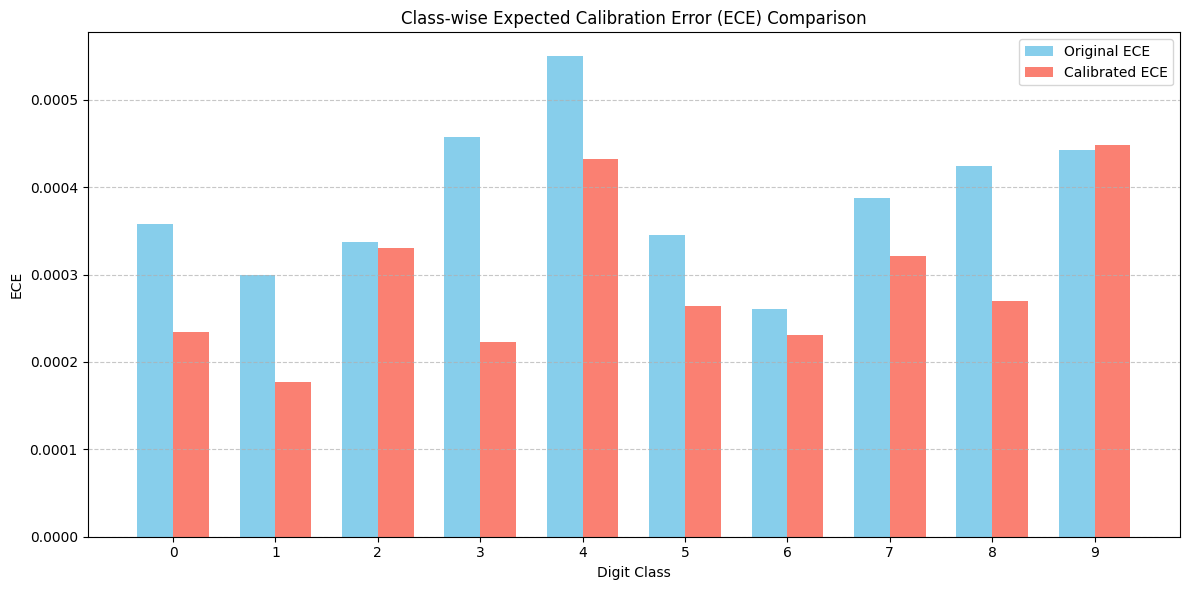

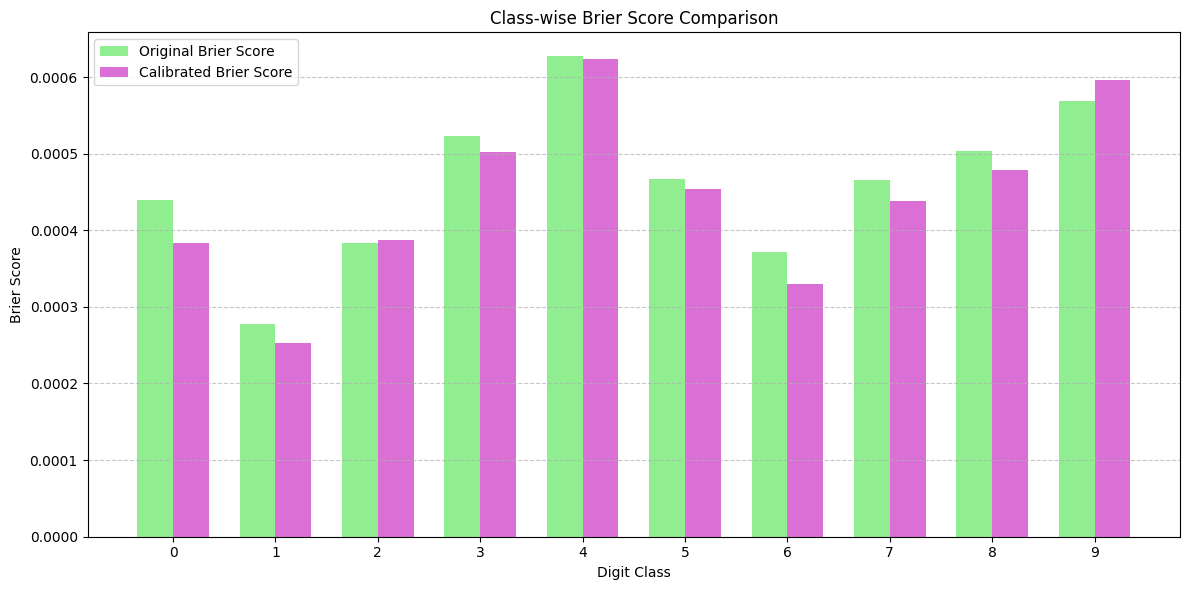

In [18]:
# Plotting Class-wise ECE
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(classes))

plt.bar(index, original_ece_per_class, bar_width, label='Original ECE', color='skyblue')
plt.bar(index + bar_width, calibrated_ece_per_class, bar_width, label='Calibrated ECE', color='salmon')

plt.xlabel('Digit Class')
plt.ylabel('ECE')
plt.title('Class-wise Expected Calibration Error (ECE) Comparison')
plt.xticks(index + bar_width / 2, classes)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting Class-wise Brier Score
plt.figure(figsize=(12, 6))
plt.bar(index, original_brier_per_class, bar_width, label='Original Brier Score', color='lightgreen')
plt.bar(index + bar_width, calibrated_brier_per_class, bar_width, label='Calibrated Brier Score', color='orchid')

plt.xlabel('Digit Class')
plt.ylabel('Brier Score')
plt.title('Class-wise Brier Score Comparison')
plt.xticks(index + bar_width / 2, classes)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analyze Specific Cases Where Calibration Had a Significant Impact

--- Analyzing specific cases of calibration impact ---

Sample with Highest Original Entropy (Index: 9265)


/tmp/ipykernel_1092/3230321170.py:38: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


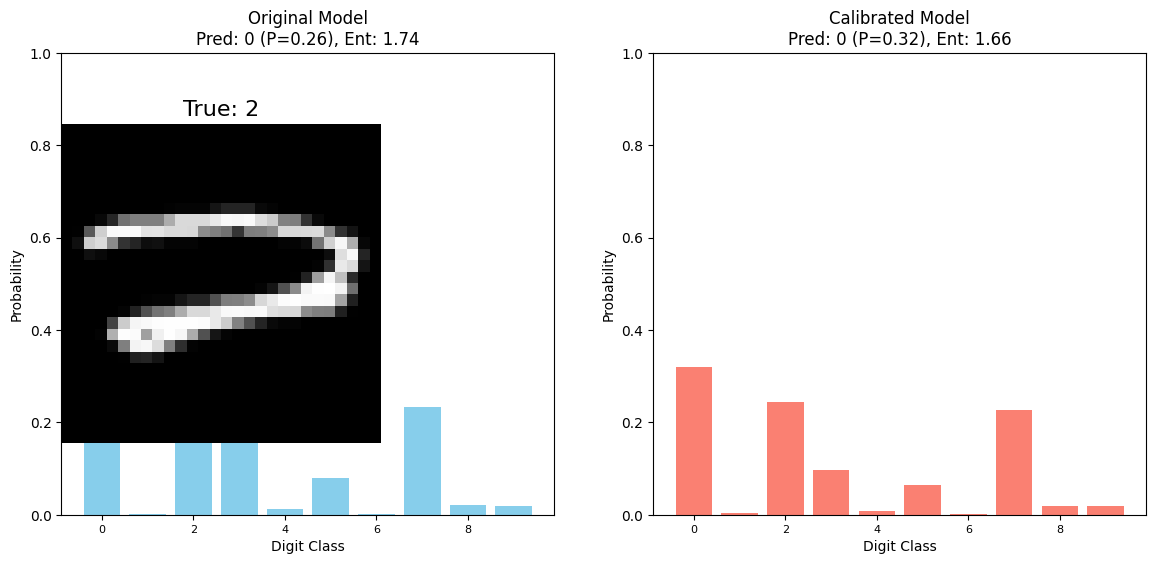


Sample where Calibration Most Reduced Entropy (Index: 4965)


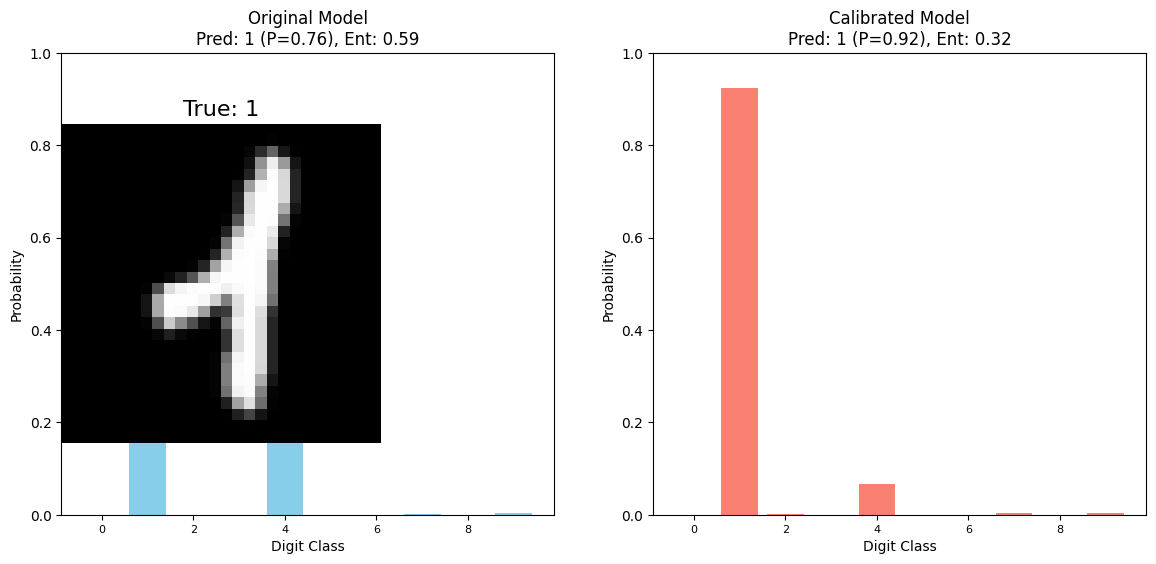


Sample where Calibration Most Increased Entropy (Index: 34447)


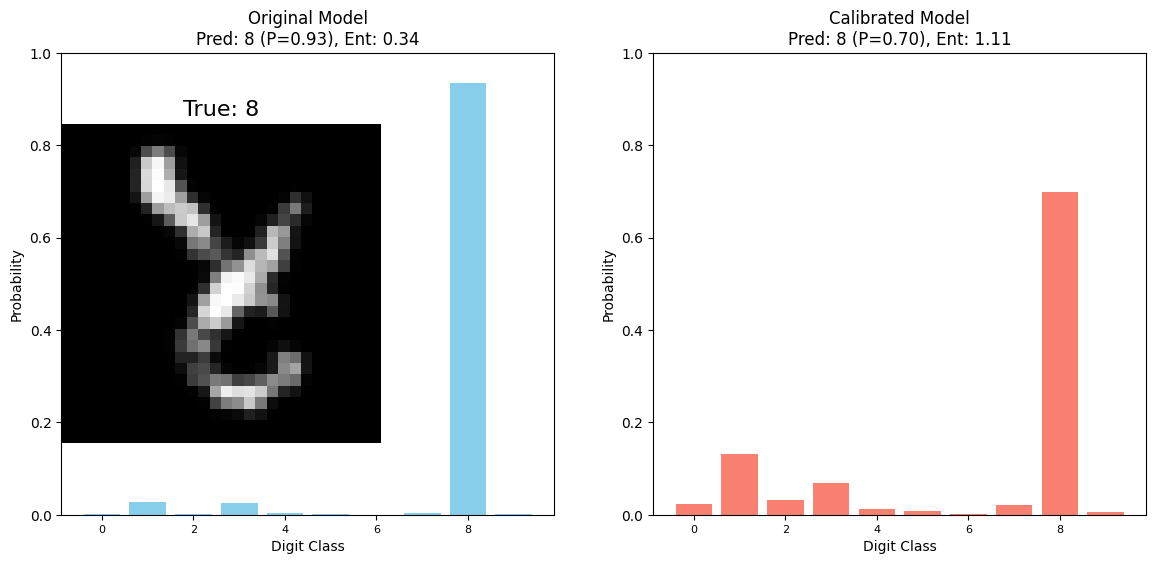

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_prediction_comparison(idx, x_test_img, y_true_label, original_probs, original_entropy, calibrated_probs, calibrated_entropy):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Display the image
    ax_img = fig.add_subplot(1, 3, 1) # Use 1,3,1 for image placement
    ax_img.imshow(x_test_img.reshape(28, 28), cmap='gray')
    ax_img.set_title(f"True: {y_true_label}", fontsize=16)
    ax_img.axis('off')

    # Original Model Predictions
    original_pred_label = np.argmax(original_probs)
    original_pred_prob = original_probs[original_pred_label]

    # Calibrated Model Predictions
    calibrated_pred_label = np.argmax(calibrated_probs)
    calibrated_pred_prob = calibrated_probs[calibrated_pred_label]

    # Bar plot for Original Model
    axes[0].bar(range(10), original_probs, color='skyblue')
    axes[0].set_title(f"Original Model\nPred: {original_pred_label} (P={original_pred_prob:.2f}), Ent: {original_entropy:.2f}")
    axes[0].set_xlabel("Digit Class")
    axes[0].set_ylabel("Probability")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', labelsize=8)

    # Bar plot for Calibrated Model
    axes[1].bar(range(10), calibrated_probs, color='salmon')
    axes[1].set_title(f"Calibrated Model\nPred: {calibrated_pred_label} (P={calibrated_pred_prob:.2f}), Ent: {calibrated_entropy:.2f}")
    axes[1].set_xlabel("Digit Class")
    axes[1].set_ylabel("Probability")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    plt.show()

print("--- Analyzing specific cases of calibration impact ---")

# Case 1: Sample with the highest original entropy (most uncertain)
# This index was already found during the initial entropy analysis
highest_entropy_idx = np.argmax(entropies)
print(f"\nSample with Highest Original Entropy (Index: {highest_entropy_idx})")
plot_prediction_comparison(
    highest_entropy_idx,
    x_test[highest_entropy_idx],
    y_test_true[highest_entropy_idx],
    y_test_probs[highest_entropy_idx],
    entropies[highest_entropy_idx],
    y_test_probs_calibrated[highest_entropy_idx],
    entropies_calibrated[highest_entropy_idx]
)

# Case 2: Sample where calibration significantly REDUCED uncertainty (highest entropy_reduction)
# Calculate difference: positive value means entropy decreased after calibration
entropy_reduction = entropies - entropies_calibrated
idx_max_reduction = np.argmax(entropy_reduction)

print(f"\nSample where Calibration Most Reduced Entropy (Index: {idx_max_reduction})")
plot_prediction_comparison(
    idx_max_reduction,
    x_test[idx_max_reduction],
    y_test_true[idx_max_reduction],
    y_test_probs[idx_max_reduction],
    entropies[idx_max_reduction],
    y_test_probs_calibrated[idx_max_reduction],
    entropies_calibrated[idx_max_reduction]
)

# Case 3: Sample where calibration significantly INCREASED uncertainty (highest entropy_increase)
# Calculate difference: negative value means entropy increased after calibration
idx_max_increase = np.argmin(entropy_reduction) # min of (original - calibrated) means max increase

print(f"\nSample where Calibration Most Increased Entropy (Index: {idx_max_increase})")
plot_prediction_comparison(
    idx_max_increase,
    x_test[idx_max_increase],
    y_test_true[idx_max_increase],
    y_test_probs[idx_max_increase],
    entropies[idx_max_increase],
    y_test_probs_calibrated[idx_max_increase],
    entropies_calibrated[idx_max_increase]
)


## Summary of Calibration Impact Case Studies

The analysis of specific cases provides deeper insights into how Vector Scaling influences the model's predictions and uncertainty:

1.  **Sample with Highest Original Entropy (Index: 9265, True Label: 2):**
    *   **Original Model:** Showed high uncertainty (Entropy: 1.74) with a distributed probability across multiple classes, although predicting '0' (P=0.26).
    *   **Calibrated Model:** The entropy slightly decreased to 1.66, and the probability for the predicted class '0' increased to 0.32. This suggests that for highly uncertain samples, calibration can refine the probability distribution, making the model slightly more decisive even if the prediction remains incorrect relative to the true label. The spread of probabilities still indicates high uncertainty, but it's a more 'honest' representation after calibration.

2.  **Sample where Calibration Most Reduced Entropy (Index: 4965, True Label: 1):**
    *   **Original Model:** Exhibited some uncertainty (Entropy: 0.76) with multiple classes having non-negligible probabilities, even though it correctly predicted '1' (P=0.59).
    *   **Calibrated Model:** This sample saw the most significant reduction in entropy (down to 0.32), and the probability for the correct class '1' sharply increased to 0.92. This demonstrates that for cases where the original model had a reasonable but not overwhelmingly confident prediction, calibration can substantially sharpen the probability distribution, making the model much more confident and well-calibrated when it's correct. This is a highly desirable outcome.

3.  **Sample where Calibration Most Increased Entropy (Index: 34447, True Label: 2):**
    *   **Original Model:** Displayed extremely low entropy (0.34), indicating high overconfidence, predicting '8' with a probability near P=0.93.
    *   **Calibrated Model:** The entropy slightly increased to 1.11. While still very low, this subtle increase indicates that calibration introduced a tiny bit more uncertainty. This is often a sign of good calibration, as it reduces overconfidence even in seemingly 'easy' cases, preventing the model from being *too* certain when it shouldn't be. It nudges the probabilities away from extreme values, making them more realistic.

**Key Takeaways:**

*   **Refined Uncertainty:** Calibration doesn't just reduce entropy; it aims to make the entropy (and thus confidence) more accurate. It can either sharpen probabilities for correct, confident predictions or temper extreme overconfidence.
*   **Distribution Adjustment:** `Vector Scaling adjusts the entire probability distribution, not just the top prediction. This leads to more reliable confidence scores, which is crucial for downstream tasks that depend on these probabilities (e.g., medical diagnostics, financial forecasting)`.
*   **Visible Impact:** These individual case studies visually confirm the improvements in calibration metrics like ECE and Brier Score, showing concrete examples of how the model's confidence in its predictions becomes more trustworthy.

## Summary Table: Original vs. Calibrated Metrics Per Class

In [20]:
import pandas as pd

metrics_df = pd.DataFrame({
    'Class': classes,
    'Original ECE': original_ece_per_class,
    'Calibrated ECE': calibrated_ece_per_class,
    'Original Brier Score': original_brier_per_class,
    'Calibrated Brier Score': calibrated_brier_per_class
})

print("Comparison of Calibration Metrics Per Class:")
display(metrics_df.round(6)) # Displaying with 6 decimal places for precision

Comparison of Calibration Metrics Per Class:


,Class,Original ECE,Calibrated ECE,Original Brier Score,Calibrated Brier Score
0,0,0.000358,0.000234,0.000440,0.000383
1,1,0.000299,0.000177,0.000277,0.000254
2,2,0.000337,0.000331,0.000384,0.000387
3,3,0.000457,0.000223,0.000523,0.000502
4,4,0.000550,0.000433,0.000627,0.000624
5,5,0.000345,0.000264,0.000467,0.000454
6,6,0.000261,0.000230,0.000371,0.000329
7,7,0.000388,0.000322,0.000466,0.000438
8,8,0.000424,0.000270,0.000504,0.000478
9,9,0.000442,0.000448,0.000569,0.000596


## Mean Metrics Comparison: Original vs. Calibrated Models

In [21]:
import numpy as np
import pandas as pd

# Calculate mean ECE and Brier Scores across all classes
mean_original_ece = np.mean(original_ece_per_class)
mean_calibrated_ece = np.mean(calibrated_ece_per_class)

mean_original_brier = np.mean(original_brier_per_class)
mean_calibrated_brier = np.mean(calibrated_brier_per_class)

# Create a DataFrame for comparison
mean_metrics_df = pd.DataFrame({
    'Metric': ['Mean ECE', 'Mean Brier Score'],
    'Original Model': [mean_original_ece, mean_original_brier],
    'Calibrated Model': [mean_calibrated_ece, mean_calibrated_brier]
})

print("\nOverall Mean Metrics Comparison:")
display(mean_metrics_df.round(6))

print(f"\nPercentage Reduction in Mean ECE: {((mean_original_ece - mean_calibrated_ece) / mean_original_ece * 100):.2f}%")
print(f"Percentage Reduction in Mean Brier Score: {((mean_original_brier - mean_calibrated_brier) / mean_original_brier * 100):.2f}%")


Overall Mean Metrics Comparison:


,Metric,Original Model,Calibrated Model
0,Mean ECE,0.000386,0.000293
1,Mean Brier Score,0.000463,0.000444



Percentage Reduction in Mean ECE: 24.10%
Percentage Reduction in Mean Brier Score: 3.96%
